# Pythia EFP Covariance

Compares the EFP covariance eigenspectrum for two processes at the same center-of-mass energy (sqrt(s) = mZ = 91.188 GeV):
- **e+e- → Z → qqbar** (light quarks u, d, s)
- **e+e- → H → gg** with mH = mZ (gluon jets)

Events are generated with Pythia8. EFPs are computed with [EnergyFlow](https://energyflow.network) package.

In [248]:
import numpy as np
import matplotlib.pyplot as plt
import energyflow as ef
import os

os.makedirs('figures', exist_ok=True)

## 1. Load Events

Text format: one particle per line (`E px py pz`), blank line between events.

In [267]:
def load_events(filepath):
    events, current = [], []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line:
                current.append([float(x) for x in line.split()])
            elif current:
                events.append(np.array(current))
                current = []
    if current:
        events.append(np.array(current))
    return events

Zqq_events = load_events('data/Zqq_events.txt')
Hgg_events = load_events('data/Hgg_events.txt')


mults_Z = [len(e) for e in Zqq_events]
mults_H = [len(e) for e in Hgg_events]
print(f'Z->qqbar: {len(Zqq_events)} events, avg multiplicity {np.mean(mults_Z):.1f} +/- {np.std(mults_Z):.1f}')
print(f'H->gg:    {len(Hgg_events)} events, avg multiplicity {np.mean(mults_H):.1f} +/- {np.std(mults_H):.1f}')

Z->qqbar: 100000 events, avg multiplicity 23.9 +/- 5.7
H->gg:    100000 events, avg multiplicity 41.2 +/- 7.4


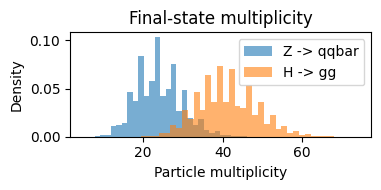

In [251]:
# Quick sanity check: plot multiplicity distributions
fig, ax = plt.subplots(figsize=(4, 2))
ax.hist(mults_Z, bins=40, alpha=0.6, label='Z -> qqbar', density=True)
ax.hist(mults_H, bins=40, alpha=0.6, label='H -> gg', density=True)
ax.set_xlabel('Particle multiplicity')
ax.set_ylabel('Density')
ax.set_title('Final-state multiplicity')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Compute EFPs

Using `measure='ee'` (appropriate for e+e- events), which uses energy fractions z_i = E_i / sum(E_j) and pairwise angles theta_ij computed from the 3-momenta directions.

Input to `batch_compute`: list of (N_particles, 4) arrays with columns (E, px, py, pz).

In [252]:
efpset_d4Beta1 = ef.EFPSet('d<=4', measure='ee', beta=1, normed=True)
efpset_d4Beta2 = ef.EFPSet('d<=4', measure='ee', beta=2, normed=True)
efpset_d5Beta1 = ef.EFPSet('d<=5', measure='ee', beta=1, normed=True)
efpset_d5Beta2 = ef.EFPSet('d<=5', measure='ee', beta=2, normed=True)

configs = [
    ('d4b1', efpset_d4Beta1, r'$d_{\leq 4},\ \beta=1$'),
    ('d4b2', efpset_d4Beta2, r'$d_{\leq 4},\ \beta=2$'),
    ('d5b1', efpset_d5Beta1, r'$d_{\leq 5},\ \beta=1$'),
    ('d5b2', efpset_d5Beta2, r'$d_{\leq 5},\ \beta=2$'),
]

efps_all = {}
for key, efpset, label in configs:
    Z = efpset.batch_compute(Zqq_events)
    H = efpset.batch_compute(Hgg_events)
    efps_all[key] = {'Z': Z, 'H': H, 'label': label}
    print(f'{key}: n_EFPs={Z.shape[1]}')

d4b1: n_EFPs=36
d4b2: n_EFPs=36
d5b1: n_EFPs=102
d5b2: n_EFPs=102


In [247]:
# Main basis used by downstream cells
eps = 1e-10
efps_Z = np.log(efps_all['d5b1']['Z'] + eps)
efps_H = np.log(efps_all['d5b1']['H'] + eps)

## 4. Covariance Matrix

In [253]:
cov_Z = np.cov(efps_Z.T)  # shape: (N_EFPs, N_EFPs)
cov_H = np.cov(efps_H.T)
print(f'Covariance matrix shape: {cov_Z.shape}')

Covariance matrix shape: (102, 102)


In [11]:
# eps = 1e-10
# log_efps_Z = np.log(efps_Z + eps)
# log_efps_H = np.log(efps_H + eps)

# cov_Z = np.cov(log_efps_Z.T)
# cov_H = np.cov(log_efps_H.T)

In [112]:
# fig, axes = plt.subplots(1, 2, figsize=(5, 2.5))
# for ax, cov, title in zip(axes, [cov_Z, cov_H], ['Z -> qqbar', 'H -> gg']):
#     im = ax.imshow(np.log10(np.abs(cov) + 1e-30), cmap='RdBu_r', aspect='auto')
#     ax.set_title(f'log10|Cov(log EFP)| — {title}', fontsize=12)
#     ax.set_xlabel('EFP index')
#     ax.set_ylabel('EFP index')
#     plt.colorbar(im, ax=ax, fraction=0.046)
# plt.tight_layout()
# plt.savefig('figures/covariance_matrices.png', dpi=150, bbox_inches='tight')
# plt.show()

## 5. Eigenspectrum

Diagonalize each covariance matrix and plot eigenvalues sorted in descending order.
The shape of this spectrum reflects how correlated the EFPs are — a steep drop means
most variance is captured by the first few eigenvectors.

In [254]:
eigvals_Z = np.sort(np.linalg.eigvalsh(cov_Z))[::-1]
eigvals_H = np.sort(np.linalg.eigvalsh(cov_H))[::-1]

# Drop any numerically negative eigenvalues (rounding noise near zero)
eigvals_Z = np.clip(eigvals_Z, 0, None)
eigvals_H = np.clip(eigvals_H, 0, None)

print(f'Z: largest eigenvalue = {eigvals_Z[0]:.4e}, smallest = {eigvals_Z[-1]:.4e}')
print(f'H: largest eigenvalue = {eigvals_H[0]:.4e}, smallest = {eigvals_H[-1]:.4e}')

Z: largest eigenvalue = 1.1168e+00, smallest = 0.0000e+00
H: largest eigenvalue = 5.7965e-01, smallest = 0.0000e+00


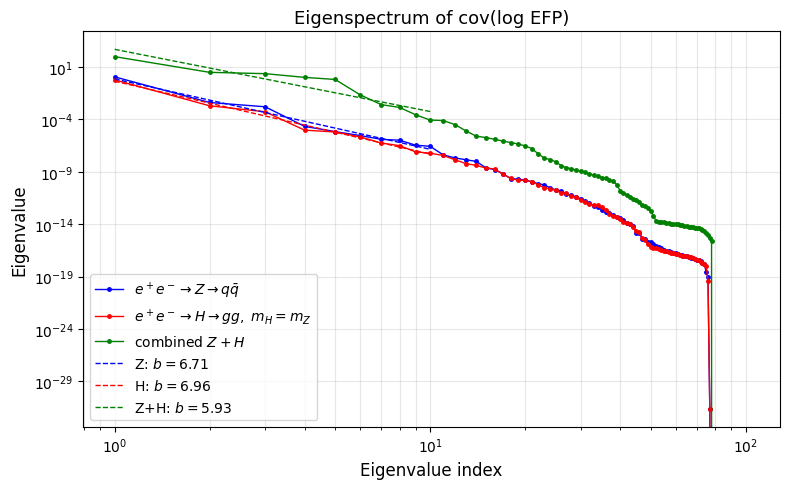

In [255]:
fig, ax = plt.subplots(figsize=(8, 5))

idx_Z = np.arange(1, len(eigvals_Z) + 1)
idx_H = np.arange(1, len(eigvals_H) + 1)

ax.loglog(idx_Z, eigvals_Z, 'b.-', markersize=5, linewidth=1,
            label=r'$e^+e^- \to Z \to q\bar{q}$')
ax.loglog(idx_H, eigvals_H, 'r.-', markersize=5, linewidth=1,
            label=r'$e^+e^- \to H \to gg,\ m_H = m_Z$')

# Combined Z+H covariance — this is what the regression and source condition use
from sklearn.preprocessing import StandardScaler
X_comb = StandardScaler().fit_transform(np.vstack([efps_Z, efps_H]))
eigvals_comb = np.sort(np.clip(np.linalg.eigvalsh(np.cov(X_comb.T)), 0, None))[::-1]
idx_comb = np.arange(1, len(eigvals_comb) + 1)
ax.loglog(idx_comb, eigvals_comb, 'g.-', markersize=5, linewidth=1,
            label=r'combined $Z+H$')

fit_cutoff = 10

for eigvals, color, name in [
    (eigvals_Z,    'b', 'Z'),
    (eigvals_H,    'r', 'H'),
    (eigvals_comb, 'g', 'Z+H'),
]:
    idx_fit = np.arange(1, fit_cutoff + 1)
    slope, log_c = np.polyfit(np.log(idx_fit), np.log(eigvals[:fit_cutoff]), 1)
    fit_vals = np.exp(log_c) * idx_fit**slope
    ax.loglog(idx_fit, fit_vals, color=color, linestyle='--', linewidth=1,
              label=f'{name}: $b = {-slope:.2f}$')

ax.set_xlabel('Eigenvalue index', fontsize=12)
ax.set_ylabel('Eigenvalue', fontsize=12)
ax.set_title('Eigenspectrum of cov(log EFP)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/eigenspectrum.png', dpi=150, bbox_inches='tight')
plt.show()

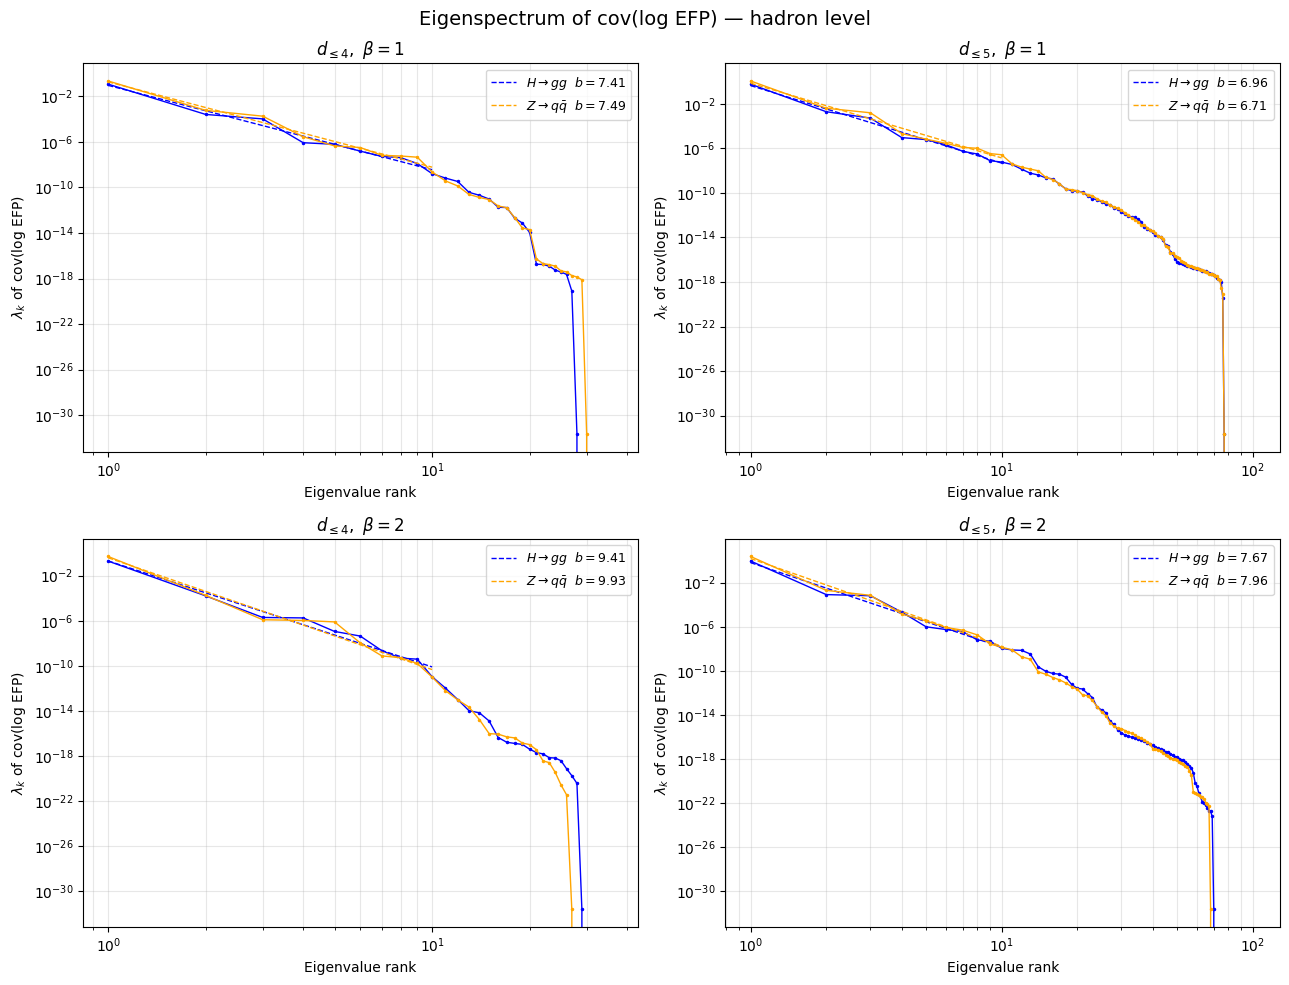

In [256]:
fit_cutoff = 10  # fit only the clean power-law region, same as single-panel plot

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
ax_map = [('d4b1', axes[0,0]), ('d5b1', axes[0,1]), ('d4b2', axes[1,0]), ('d5b2', axes[1,1])]

for key, ax in ax_map:
    for sample, color, slabel in [('H', 'b', r'$H\to gg$'), ('Z', 'orange', r'$Z\to q\bar{q}$')]:
        raw = efps_all[key][sample]
        eigvals = np.clip(np.sort(np.linalg.eigvalsh(np.cov(np.log(raw + eps).T)))[::-1], 0, None)
        idx = np.arange(1, len(eigvals) + 1)
        ax.loglog(idx, eigvals, color=color, marker='.', markersize=3, linewidth=1)
        idx_fit = np.arange(1, fit_cutoff + 1)
        slope, log_c = np.polyfit(np.log(idx_fit), np.log(eigvals[:fit_cutoff]), 1)
        ax.loglog(idx_fit, np.exp(log_c) * idx_fit**slope, color=color,
                  linestyle='--', linewidth=1, label=f'{slabel}  $b={-slope:.2f}$')
    ax.set_title(efps_all[key]['label'], fontsize=12)
    ax.set_xlabel('Eigenvalue rank', fontsize=10)
    ax.set_ylabel(r'$\lambda_k$ of cov(log EFP)', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, which='both', alpha=0.3)

plt.suptitle('Eigenspectrum of cov(log EFP) — hadron level', fontsize=14)
plt.tight_layout()
plt.savefig('figures/eigenspectrum_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Linear Regression: EFPs → Quark/Gluon Label

Combine both samples with labels 0 (Z→qqbar) and 1 (H→gg). Train linear regression on
subsets of increasing size and plot test loss vs number of training events.

In [257]:
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import numpy as np

# Combine log EFPs and labels
X = np.vstack([efps_Z, efps_H])
y = np.array([0] * len(efps_Z) + [1] * len(efps_H), dtype=float)

rng = np.random.default_rng(42)
idx = rng.permutation(len(X))
X, y = X[idx], y[idx]

X_test, y_test   = X[-20000:], y[-20000:]
X_train, y_train = X[:-20000], y[:-20000]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Fixed ridge penalty r — RidgeCV selects r optimal for large N,
# which is too small for small-N subsets and causes instability.
# r = RidgeCV(alphas=np.logspace(-4, 4, 50), cv=5).fit(X_train_s, y_train).alpha_
r = 1e-2
print(f'Fixed ridge r = {r:.4e}')

train_sizes = [5, 8, 10, 15, 25, 50, 75, 100, 150, 200, 300, 500, 700, 1000, 1500, 2000, 3000, 5000, 8000]
train_sizes = [5, 8, 10, 15, 25, 50, 75, 100, 150, 200, 300, 500, 700, 1000, 1500, 2000, 3000, 5000, 8000, 15000, 30000, 60000, 120000, 160000]
test_losses = []
n_repeats = 500

print("Train size | Test MSE (avg over repeats)")
for n in train_sizes:
    losses_n = []
    for seed in range(n_repeats):
        sub_idx = np.random.default_rng(seed).choice(len(X_train_s), size=n, replace=False)
        reg = Ridge(alpha=r).fit(X_train_s[sub_idx], y_train[sub_idx])
        losses_n.append(mean_squared_error(y_test, reg.predict(X_test_s)))
    mean_loss = np.mean(losses_n)
    test_losses.append(mean_loss)
    print(f"  {n:6d}   |  {mean_loss:.6f}")

Fixed ridge r = 1.0000e-02
Train size | Test MSE (avg over repeats)
       5   |  1.100777
       8   |  0.286151
      10   |  0.189856
      15   |  0.101626
      25   |  0.077098
      50   |  0.079345
      75   |  0.084024
     100   |  0.092235
     150   |  0.112843
     200   |  0.116749
     300   |  0.121773
     500   |  0.134433
     700   |  0.118105
    1000   |  0.114572
    1500   |  0.080432
    2000   |  0.077020
    3000   |  0.065362
    5000   |  0.049447
    8000   |  0.045856
   15000   |  0.042878
   30000   |  0.042259
   60000   |  0.041968
  120000   |  0.041748
  160000   |  0.041658


Estimated irreducible floor: 0.041658


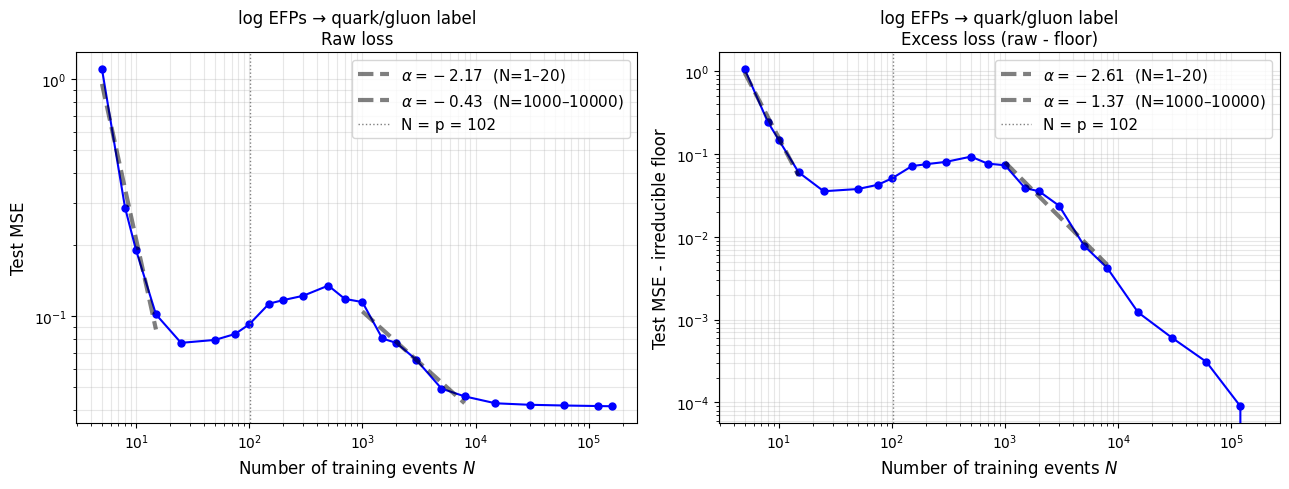

In [270]:
fit_n_min_1 = 1
fit_n_max_1 = 20

fit_n_min_2 = 1000
fit_n_max_2 = 10000

floor = test_losses[-1]
excess_losses = [l - floor for l in test_losses]
print(f'Estimated irreducible floor: {floor:.6f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, losses, title, ylabel, exclude_last in zip(
    axes,
    [test_losses, excess_losses],
    ['Raw loss', 'Excess loss (raw - floor)'],
    ['Test MSE', 'Test MSE - irreducible floor'],
    [False, True]
):
    ax.loglog(train_sizes, losses, 'bo-', markersize=5)

    ns_all = train_sizes[:-1] if exclude_last else train_sizes
    ls_all = losses[:-1]      if exclude_last else losses

    mask_1 = [fit_n_min_1 <= n <= fit_n_max_1 for n in ns_all]
    ns_fit_1 = [n for n, m in zip(ns_all, mask_1) if m]
    ls_fit_1 = [l for l, m in zip(ls_all, mask_1) if m]

    mask_2 = [fit_n_min_2 <= n <= fit_n_max_2 for n in ns_all]
    ns_fit_2 = [n for n, m in zip(ns_all, mask_2) if m]
    ls_fit_2 = [l for l, m in zip(ls_all, mask_2) if m]

    if len(ns_fit_1) >= 2:
        slope_1, log_c_1 = np.polyfit(np.log(ns_fit_1), np.log(ls_fit_1), 1)
        ax.loglog(ns_fit_1, np.exp(log_c_1) * np.array(ns_fit_1)**slope_1, 'k--', linewidth=3, alpha=0.5,
                  label=f'$\\alpha = {slope_1:.2f}$  (N={fit_n_min_1}–{fit_n_max_1})')
        
    if len(ns_fit_2) >= 2:
        slope_2, log_c_2 = np.polyfit(np.log(ns_fit_2), np.log(ls_fit_2), 1)
        ax.loglog(ns_fit_2, np.exp(log_c_2) * np.array(ns_fit_2)**slope_2, 'k--', linewidth=3, alpha=0.5,
                  label=f'$\\alpha = {slope_2:.2f}$  (N={fit_n_min_2}–{fit_n_max_2})')

    ax.axvline(102, color='gray', linestyle=':', linewidth=1, label='N = p = 102')
    ax.set_xlabel('Number of training events $N$', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f'log EFPs → quark/gluon label\n{title}', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/scaling_law_label.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Linear Regression: EFPs → Thrust

Thrust is IRC-safe and well-approximated by low-d EFPs, so the irreducible floor should be near zero.

In [259]:
def compute_thrust(event):
    """Thrust for an e+e- event. event: (N,4) array (E,px,py,pz)."""
    momenta = event[:, 1:4]                      # \vec{p}
    norms = np.linalg.norm(momenta, axis=1)      # |\vec{p}|
    momenta = momenta[norms > 1e-10]             # get rid of 
    norms = norms[norms > 1e-10]                 # particles with 0 norm ... 
    denom = np.sum(norms)                        # sum_i |p_i| 
    best_T = 0.
    for i in range(len(momenta)):                  # only scanning over momenta in the event ...  
        n = momenta[i] / norms[i]                  # \hat{p}
        T = np.sum(np.abs(momenta @ n)) / denom    # sum_i |  |
        if T > best_T:
            best_T = T
    return best_T


def compute_thrust_iterative(event, max_iter=20):
    """Exact thrust via iterated hemisphere refinement. event: (N,4) array (E,px,py,pz)."""
    momenta = event[:, 1:4]                        # \vec{p}
    norms = np.linalg.norm(momenta, axis=1)        # |\vec{p}|
    momenta = momenta[norms > 1e-10]
    norms = norms[norms > 1e-10]
    denom = np.sum(norms)     
    best_T = 0.
    for i in range(len(momenta)):
        n = momenta[i] / norms[i]
        for _ in range(max_iter):
            signs = np.sign(momenta @ n)       # assigns each momenta to a hemisphere +/-
            signs[signs == 0] = 1.
            n_new = signs @ momenta            # optimal axis is sum of momenta on + hemisphere
            norm_new = np.linalg.norm(n_new) 
            if norm_new < 1e-10:
                break
            n_new /= norm_new
            if np.abs(1. - np.abs(n_new @ n)) < 1e-12:  # check convergence
                break
            n = n_new
        T = np.sum(np.abs(momenta @ n)) / denom
        if T > best_T:
            best_T = T
    return best_T

In [260]:
thrust_Z = np.array([compute_thrust(e) for e in Zqq_events])
thrust_H = np.array([compute_thrust(e) for e in Hgg_events])

print(f'Z->qqbar: mean thrust = {np.mean(thrust_Z):.4f} +/- {np.std(thrust_Z):.4f}')
print(f'H->gg:    mean thrust = {np.mean(thrust_H):.4f} +/- {np.std(thrust_H):.4f}')

Z->qqbar: mean thrust = 0.9872 +/- 0.0052
H->gg:    mean thrust = 0.9719 +/- 0.0078


In [261]:
thrust_Z = np.array([compute_thrust_iterative(e) for e in Zqq_events])
thrust_H = np.array([compute_thrust_iterative(e) for e in Hgg_events])

print(f'Z->qqbar: mean thrust = {np.mean(thrust_Z):.4f} +/- {np.std(thrust_Z):.4f}')
print(f'H->gg:    mean thrust = {np.mean(thrust_H):.4f} +/- {np.std(thrust_H):.4f}')

Z->qqbar: mean thrust = 0.9873 +/- 0.0052
H->gg:    mean thrust = 0.9720 +/- 0.0078


In [263]:
# Use d<=4 log EFPs — thrust is in the d<=2 span so d<=4 is more than sufficient
X_t = np.vstack([np.log(efps_all['d4b1']['Z'] + eps), np.log(efps_all['d4b1']['H'] + eps)])
y_t = np.concatenate([thrust_Z, thrust_H])

rng_t = np.random.default_rng(42)
idx_t = rng_t.permutation(len(X_t))
X_t, y_t = X_t[idx_t], y_t[idx_t]

X_t_test, y_t_test   = X_t[-20000:], y_t[-20000:]
X_t_train, y_t_train = X_t[:-20000], y_t[:-20000]

scaler_t = StandardScaler()
X_t_train_s = scaler_t.fit_transform(X_t_train)
X_t_test_s  = scaler_t.transform(X_t_test)

r_thrust = 1e-2
train_sizes_t = [5, 8, 10, 15, 25, 50, 75, 100, 150, 200, 300, 500, 700, 1000, 1500, 2000, 3000, 5000, 8000]
train_sizes_t = [5, 8, 10, 15, 25, 50, 75, 100, 150, 200, 300, 500, 700, 1000, 1500, 2000, 3000, 5000, 8000, 15000, 30000, 60000, 120000, 160000]

test_losses_t = []
n_repeats_t = 500

print("Train size | Test MSE (thrust, log EFPs)")
for n in train_sizes_t:
    losses_n = []
    for seed in range(n_repeats_t):
        sub_idx = np.random.default_rng(seed).choice(len(X_t_train_s), size=n, replace=False)
        reg = Ridge(alpha=r_thrust).fit(X_t_train_s[sub_idx], y_t_train[sub_idx])
        losses_n.append(mean_squared_error(y_t_test, reg.predict(X_t_test_s)))
    test_losses_t.append(np.mean(losses_n))
    print(f"  {n:6d}   |  {test_losses_t[-1]:.6f}")

Train size | Test MSE (thrust, log EFPs)
       5   |  0.000159
       8   |  0.000060
      10   |  0.000040
      15   |  0.000027
      25   |  0.000024
      50   |  0.000023
      75   |  0.000023
     100   |  0.000026
     150   |  0.000027
     200   |  0.000026
     300   |  0.000028
     500   |  0.000026
     700   |  0.000027
    1000   |  0.000020
    1500   |  0.000016
    2000   |  0.000014
    3000   |  0.000011
    5000   |  0.000009
    8000   |  0.000008
   15000   |  0.000008
   30000   |  0.000007
   60000   |  0.000007
  120000   |  0.000007
  160000   |  0.000007


Floor estimate (N=8000): 0.000007


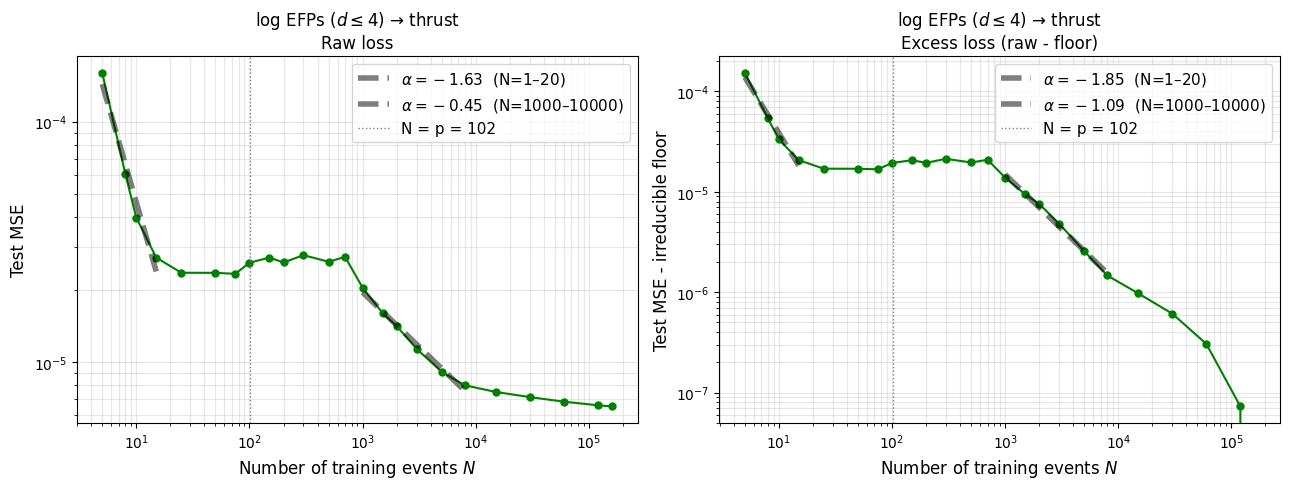

In [269]:
fit_n_min_t_1 = 1
fit_n_max_t_1 = 20 

fit_n_min_t_2 = 1000
fit_n_max_t_2 = 10000

floor_t = test_losses_t[-1]
excess_losses_t = [l - floor_t for l in test_losses_t]
print(f'Floor estimate (N=8000): {floor_t:.6f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, losses, title, ylabel, exclude_last in zip(
    axes,
    [test_losses_t, excess_losses_t],
    ['Raw loss', 'Excess loss (raw - floor)'],
    ['Test MSE', 'Test MSE - irreducible floor'],
    [False, True]
):
    ax.loglog(train_sizes_t, losses, 'go-', markersize=5)

    ns_all = train_sizes_t[:-1] if exclude_last else train_sizes_t
    ls_all = losses[:-1]        if exclude_last else losses

    mask_1 = [fit_n_min_t_1 <= n <= fit_n_max_t_1 for n in ns_all]
    ns_fit_1 = [n for n, m in zip(ns_all, mask_1) if m]
    ls_fit_1 = [l for l, m in zip(ls_all, mask_1) if m]

    mask_2 = [fit_n_min_t_2 <= n <= fit_n_max_t_2 for n in ns_all]
    ns_fit_2 = [n for n, m in zip(ns_all, mask_2) if m]
    ls_fit_2 = [l for l, m in zip(ls_all, mask_2) if m]

    if len(ns_fit_1) >= 2:
        slope_1, log_c_1 = np.polyfit(np.log(ns_fit_1), np.log(ls_fit_1), 1)
        ax.loglog(ns_fit_1, np.exp(log_c_1) * np.array(ns_fit_1)**slope_1, 'k--', linewidth=4, alpha=0.5,
                  label=f'$\\alpha = {slope_1:.2f}$  (N={fit_n_min_t_1}–{fit_n_max_t_1})')
        
    if len(ns_fit_2) >= 2:
        slope_2, log_c_2 = np.polyfit(np.log(ns_fit_2), np.log(ls_fit_2), 1)
        ax.loglog(ns_fit_2, np.exp(log_c_2) * np.array(ns_fit_2)**slope_2, 'k--', linewidth=4, alpha=0.5,
                  label=f'$\\alpha = {slope_2:.2f}$  (N={fit_n_min_t_2}–{fit_n_max_t_2})')
                  

    ax.axvline(102, color='gray', linestyle=':', linewidth=1, label='N = p = 102')
    ax.set_xlabel('Number of training events $N$', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f'log EFPs ($d\\leq 4$) → thrust\n{title}', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/scaling_law_thrust.png', dpi=150, bbox_inches='tight')
plt.show()

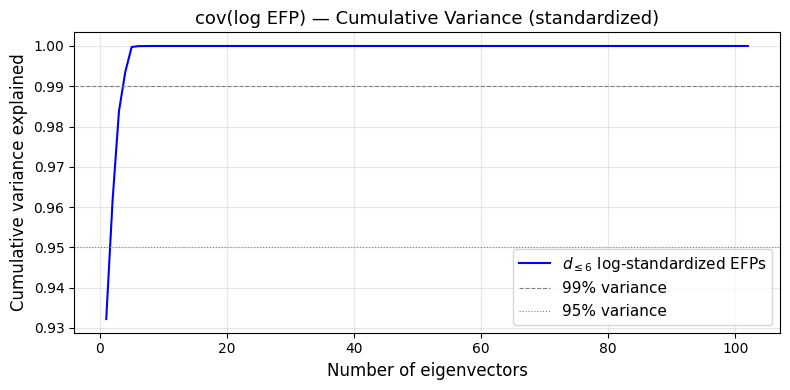

95% variance explained by 2 eigenvectors (out of 102)
99% variance explained by 4 eigenvectors (out of 102)


In [266]:
# Cumulative variance — log-standardized covariance (matches regression)
from sklearn.preprocessing import StandardScaler

X_cum = StandardScaler().fit_transform(np.vstack([efps_Z, efps_H]))
eigvals_cum = np.sort(np.clip(np.linalg.eigvalsh(np.cov(X_cum.T)), 0, None))[::-1]
cum_var = np.cumsum(eigvals_cum) / np.sum(eigvals_cum)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, len(cum_var) + 1), cum_var, 'b-', label=r'$d_{\leq 6}$ log-standardized EFPs')
ax.axhline(0.99, color='gray', linestyle='--', linewidth=0.8, label='99% variance')
ax.axhline(0.95, color='gray', linestyle=':', linewidth=0.8, label='95% variance')
ax.set_xlabel('Number of eigenvectors', fontsize=12)
ax.set_ylabel('Cumulative variance explained', fontsize=12)
ax.set_title('cov(log EFP) — Cumulative Variance (standardized)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/cumulative_variance.png', dpi=150, bbox_inches='tight')
plt.show()

for thresh, label in [(0.95, '95%'), (0.99, '99%')]:
    n = np.searchsorted(cum_var, thresh) + 1
    print(f'{label} variance explained by {n} eigenvectors (out of {len(cum_var)})')